<a href="https://colab.research.google.com/github/Narendrafulwaria/cognevance_student-performance-analysis/blob/main/Cognevance_Student_Performance_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("raw_student_data.csv")

# check missing value
df.isnull().sum()

# Identify numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Fill missing values in only the numeric columns with their respective means
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# check duplicates
df.duplicated().sum()

# drop duplicates
df = df.drop_duplicates(inplace=False)
df.duplicated().sum()

# check data consistency
df['test_preparation'] = df['test_preparation'].str.title().str.strip()
df['test_preparation'] = df['test_preparation'].fillna('Not Reported') # Impute missing values
df = df[df['test_preparation'] != 'None'] # Correctly filter out rows where 'test_preparation' is 'None'
df['test_preparation'].unique()

print("Dataframe info")
print(df.info())

print("Dataframe numerical column statistical data")
print(df.describe())

print("Categorical column counts")
for col in ["gender","test_preparation","parental_education"]:
  print(col)
  print(df[col].value_counts())

Dataframe info
<class 'pandas.core.frame.DataFrame'>
Index: 1497 entries, 0 to 1505
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            1497 non-null   object 
 1   name                  1497 non-null   object 
 2   gender                1497 non-null   object 
 3   grade                 1497 non-null   int64  
 4   subject               1497 non-null   object 
 5   marks                 1497 non-null   float64
 6   attendance_%          1497 non-null   float64
 7   study_hours_per_week  1497 non-null   float64
 8   test_preparation      1497 non-null   object 
 9   parental_education    1497 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 128.6+ KB
None
Dataframe numerical column statistical data
             grade        marks  attendance_%  study_hours_per_week
count  1497.000000  1497.000000   1497.000000           1497.000000
mean     10.371409    

In [ ]:
#Hypothesis Generation Prompt

"""
You are a expert data analyst
Based on the context shared

schema:
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            1501 non-null   object
 1   name                  1501 non-null   object
 2   gender                1501 non-null   object
 3   grade                 1501 non-null   int64
 4   subject               1501 non-null   object
 5   marks                 1501 non-null   float64
 6   attendance_%          1501 non-null   float64
 7   study_hours_per_week  1501 non-null   float64
 8   test_preparation      939 non-null    object
 9   parental_education    1501 non-null   object
dtypes: float64(3), int64(1), object(6)

Dataframe numerical column statistical data
             grade        marks  attendance_%  study_hours_per_week
count  1501.000000  1501.000000   1501.000000           1501.000000
mean     10.371086    80.355507     84.996734              3.556762
std       1.090047    11.647450     10.068522              1.702704
min       9.000000    36.300000     54.600000              0.000000
25%       9.000000    73.000000     78.000000              2.300000
50%      10.000000    81.000000     85.500000              3.500000
75%      11.000000    88.200000     93.300000              4.700000
max      12.000000   100.000000    100.000000              7.900000
Categorical column counts
gender
gender
Female    796
Male      705
Name: count, dtype: int64
test_preparation
test_preparation
Occasional      560
Regular         369
OCCASIONAL        5
NONE              4
REGULAR           1
Name: count, dtype: int64
parental_education
parental_education
High School    556
Bachelor's     530
Master's       300
PhD            115
Name: count, dtype: int64

Task: Create a 6-7 grounded hypothesis strictly based on shared context
Don't deviate from shared column data and don't make assumption

Format:Give me output in series numbered from 1

"""



In [ ]:
#Hypothesis

"""
1)Hypothesis: Students with higher attendance percentages tend to have higher marks.
2)Hypothesis: Students who spend more study hours per week tend to achieve higher marks.
3)Hypothesis: Students with Regular test preparation tend to have higher marks than students with Occasional test preparation.
4)Hypothesis: Students with higher attendance and more study hours per week may achieve higher marks than students with lower attendance and fewer study hours.
5)Hypothesis: Students whose parents have higher levels of education tend to have higher marks.
6)Hypothesis: Female and male students may have different average marks, which can be tested using the gender and marks columns.
7)Hypothesis: Average marks differ across grades (9–12), meaning grade level may be associated with student performance.
"""

In [46]:
#Exploratory Data Analysis
#Check if Hypothesis is verified or busted
#Create buckets of grade,attendance percentage,Study hours per week

df['attendance_%_bucket'] = pd.cut(df['attendance_%'],
                            bins=[0, 30, 50, 70, 90, 100],
                            labels=['Very Low(0-30)', 'Low(30-50)', 'Medium(50-70)', 'High(70-90)', 'Very High(90-100)'])

df['study_hours_per_week_bucket'] = pd.cut(df['study_hours_per_week'],
                            bins=[0, 2, 4, 6, 8, 10],
                            labels=['Very Low(0-2)', 'Low(2-4)', 'Medium(4-6)', 'High(6-8)', 'Very High(8-10)'])


#1)Hypothesis: Students with higher attendance percentages tend to have higher marks.

df_Hypothesis_01 = df.groupby("attendance_%_bucket").agg({"marks":"mean"}).sort_values(by="marks",ascending=False)
print(df_Hypothesis_01)

#Inference
#Students who fall in higher attendance bucket tends to score overall average marks,

#2)Hypothesis: Students who spend more study hours per week tend to achieve higher marks.

df_Hypothesis_02 = df.groupby("study_hours_per_week_bucket").agg({"marks":"mean"}).sort_values(by="marks",ascending=False)
print(df_Hypothesis_02)

#Inference
#study_hours per week is almost directly proportional to marks

#3)Hypothesis: Students with Regular test preparation tend to have higher marks than students with Occasional test preparation.

df_Hypothesis_03 = df.groupby("test_preparation").agg({"marks":"mean"}).sort_values(by="marks",ascending=False)
print(df_Hypothesis_03)

#Inference
#Occasional and Not reported have slighly higher average marks than student with regular preparation

#4)Hypothesis: Students with higher attendance and more study hours per week may achieve higher marks than students with lower attendance and fewer study hours.

df_Hypothesis_04 = df.groupby(["attendance_%","study_hours_per_week"]).agg({"marks":"mean"}).sort_values(by="marks",ascending=False)
print(df_Hypothesis_04)

#inference
#Marks dosen't necessarily depends on both(attendance_% an study_hours_per_Week)
#as we can see a student with 100% attendance and 5 hours study hour per week have
#scored 100 marks,person with 89.5% attendance and 4.2hours study hour per week have scored 99.36 marks


#5)Hypothesis: Students whose parents have higher levels of education tend to have higher marks.

df_Hypothesis_05 = df.groupby('parental_education')['marks'].mean().sort_values(ascending=False)
print(df_Hypothesis_05)

#Inference
#Parental_education doesn't affect students marks

#6)Hypothesis: Female and male students may have different average marks, which can be tested using the gender and marks columns.

df_Hypothesis_06 = df.groupby('gender')['marks'].mean().sort_values(ascending=False)
print(df_Hypothesis_06)

#Inference
#Male and Female have similar marks

#7)Hypothesis: Average marks differ across grades (9–12), meaning grade level may be associated with student performance.

df_Hypothesis_07 = df.groupby('grade')['marks'].mean().sort_values(ascending=False)
print(df_Hypothesis_07)

#Inference
#Grade doesn't affect students marks


#8)Hypothesis: Average marks Mathematics is Lowest

df_Hypothesis_08 = df.groupby('subject')['marks'].mean().sort_values(ascending=False)
print(df_Hypothesis_08)


                         marks
attendance_%_bucket           
Very High(90-100)    84.749387
High(70-90)          78.617049
Medium(50-70)        74.114545
Very Low(0-30)             NaN
Low(30-50)                 NaN
                                 marks
study_hours_per_week_bucket           
High(6-8)                    89.019167
Medium(4-6)                  81.966794
Low(2-4)                     80.000679
Very Low(0-2)                75.074637
Very High(8-10)                    NaN
                      marks
test_preparation           
Occasional        81.445994
Not Reported      80.081075
Regular           79.021796
                                        marks
attendance_% study_hours_per_week            
100.0        5.1                   100.000000
             5.0                    99.433333
89.5         4.2                    99.360000
88.6         6.4                    99.080000
87.9         6.9                    98.880000
...                                       ...
82

/tmp/ipykernel_979/1340883980.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_Hypothesis_01 = df.groupby("attendance_%_bucket").agg({"marks":"mean"}).sort_values(by="marks",ascending=False)
/tmp/ipykernel_979/1340883980.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_Hypothesis_02 = df.groupby("study_hours_per_week_bucket").agg({"marks":"mean"}).sort_values(by="marks",ascending=False)


In [47]:
#Advanced Exploratory Data Analysis

# TECHNIQUE 1: Multi-level segmentation
# Question it answers: "Does pattern X hold equally across all sub-groups?"
# How: groupby on two columns simultaneously


print(df.groupby(['attendance_%_bucket','study_hours_per_week_bucket'])['marks'].mean())

#Inferenece
#Students attending 70%-90% of classes and studying 6-8hrs per week have the best average marks of 90.69
#Students attending 50-70% of classes and studying 0-2hrs per week have the lowest average marks of 68.14



# TECHNIQUE 2: Correlation
# Question it answers: "How strongly do two numeric columns move together?"
# How: df.corr() — a matrix of pairwise relationships

numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols].corr()

#Inference
#Marks and attendance percent are positvely moderately correlated(0.37)


# TECHNIQUE 3: Outlier detection
# Question it answers: "Are extreme values distorting my summaries?"
# How: IQR method — flag values beyond Q1 − 1.5×IQR or Q3 + 1.5×IQR

Q1 = df['marks'].quantile(0.25)
Q3 = df['marks'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = 1.5 * IQR

Lower_bound = Q1 - outlier_threshold
Upper_bound = Q3 + outlier_threshold

outliers = df[(df['marks'] < Lower_bound) | (df['marks'] > Upper_bound)]
print("Number of outliers", len(outliers))
print(outliers)

attendance_%_bucket  study_hours_per_week_bucket
Very Low(0-30)       Very Low(0-2)                        NaN
                     Low(2-4)                             NaN
                     Medium(4-6)                          NaN
                     High(6-8)                            NaN
                     Very High(8-10)                      NaN
Low(30-50)           Very Low(0-2)                        NaN
                     Low(2-4)                             NaN
                     Medium(4-6)                          NaN
                     High(6-8)                            NaN
                     Very High(8-10)                      NaN
Medium(50-70)        Very Low(0-2)                  68.140000
                     Low(2-4)                       75.990000
                     Medium(4-6)                    75.835385
                     High(6-8)                            NaN
                     Very High(8-10)                      NaN
High(70-90)          

/tmp/ipykernel_979/2225475859.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['attendance_%_bucket','study_hours_per_week_bucket'])['marks'].mean())


### Students who fall in higher attendance bucket tend to score overall average marks

/tmp/ipykernel_979/1847852594.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_Hypothesis_01.index, y=df_Hypothesis_01['marks'], palette='viridis')


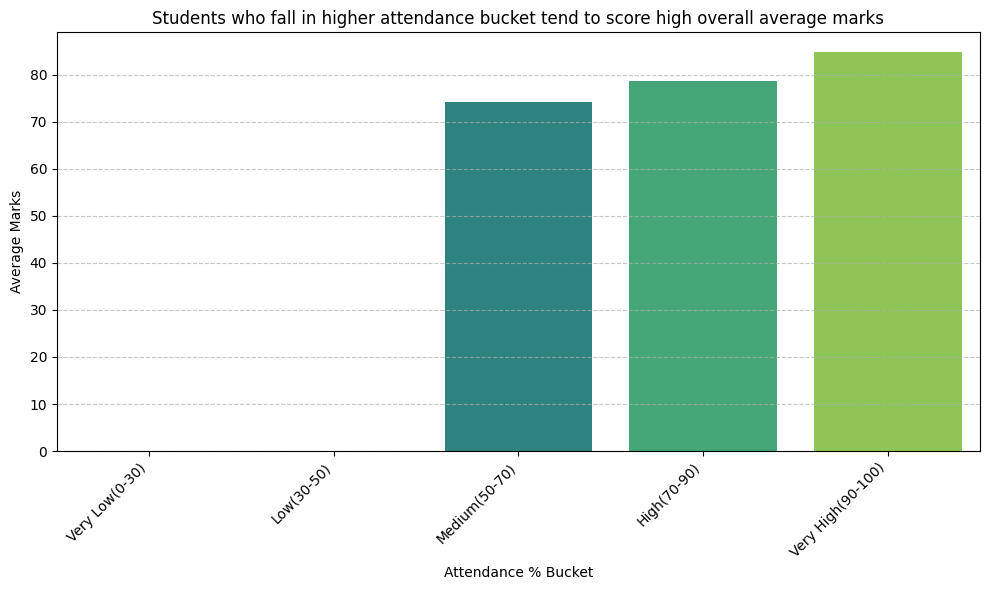

<Figure size 640x480 with 0 Axes>

In [48]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_Hypothesis_01.index, y=df_Hypothesis_01['marks'], palette='viridis')
plt.title('Students who fall in higher attendance bucket tend to score high overall average marks')
plt.xlabel('Attendance % Bucket')
plt.ylabel('Average Marks')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.savefig('average_marks_by_attendance_bucket.jpeg')

### Impact of Attendance and Study Hours on Average Marks

/tmp/ipykernel_979/2809642222.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_heatmap_data = df.groupby(['attendance_%_bucket', 'study_hours_per_week_bucket'])['marks'].mean().unstack()


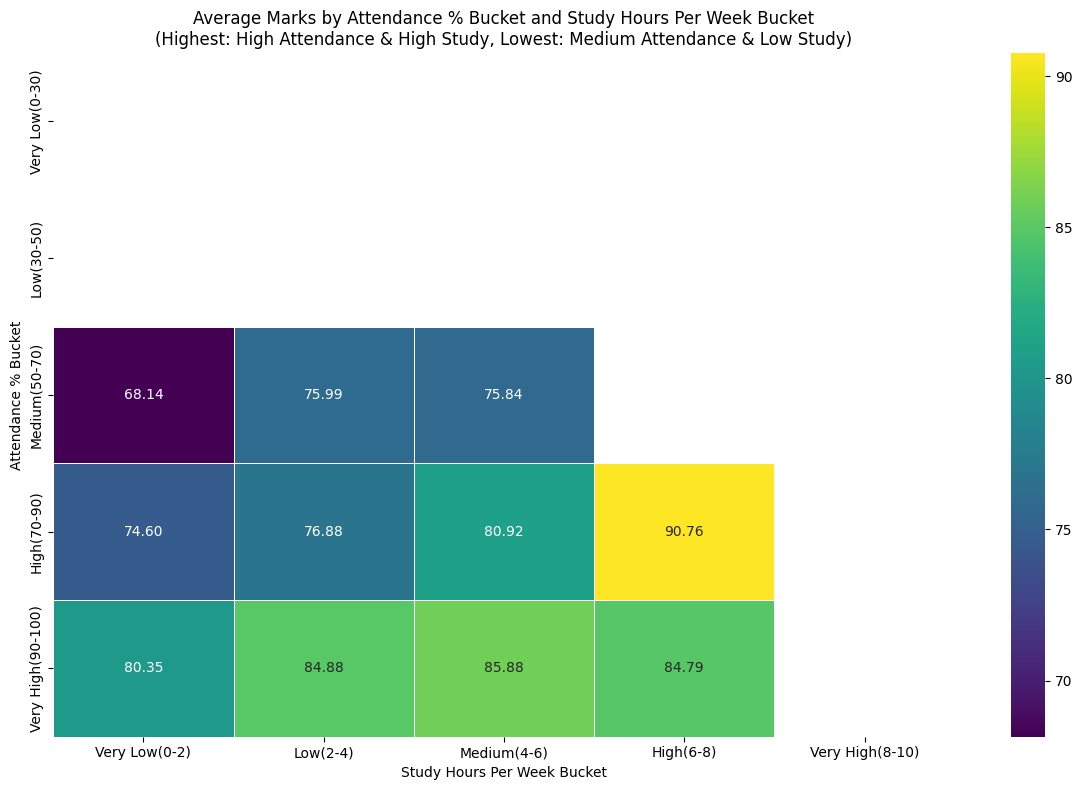

<Figure size 640x480 with 0 Axes>

In [49]:
# Group data by attendance and study hours buckets and calculate mean marks
df_heatmap_data = df.groupby(['attendance_%_bucket', 'study_hours_per_week_bucket'])['marks'].mean().unstack()

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap_data, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Average Marks by Attendance % Bucket and Study Hours Per Week Bucket\n(Highest: High Attendance & High Study, Lowest: Medium Attendance & Low Study)')
plt.xlabel('Study Hours Per Week Bucket')
plt.ylabel('Attendance % Bucket')
plt.tight_layout()
plt.show()
plt.savefig('average_marks_by_attendance_and_study_hours.jpeg')

### Relationship between Marks and Attendance Percentage

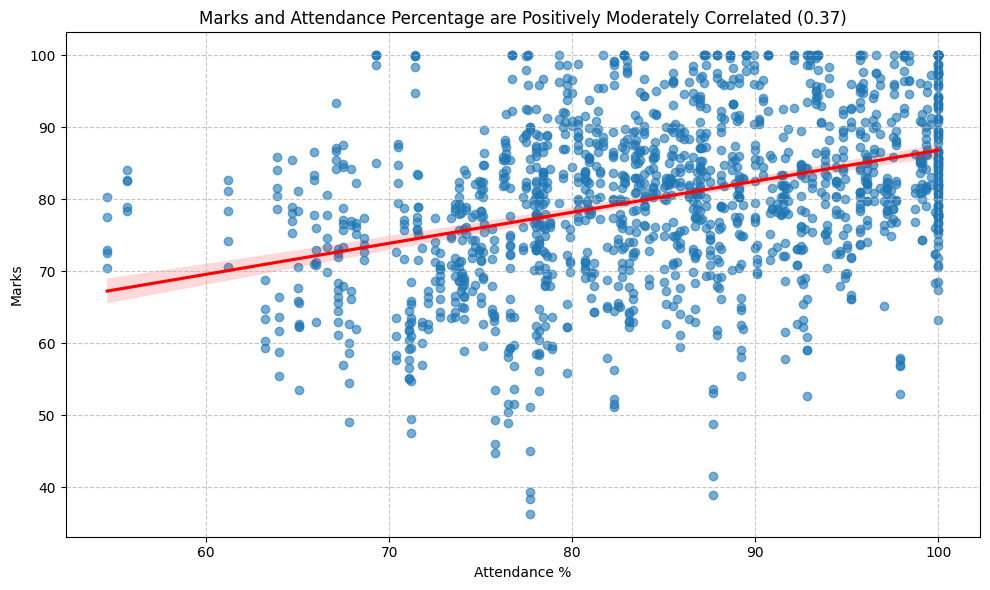

<Figure size 640x480 with 0 Axes>

In [50]:
plt.figure(figsize=(10, 6))
sns.regplot(x='attendance_%', y='marks', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Marks and Attendance Percentage are Positively Moderately Correlated (0.37)')
plt.xlabel('Attendance %')
plt.ylabel('Marks')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.savefig('marks_vs_attendance_correlation.jpeg')

### Outlier Detection using IQR Method

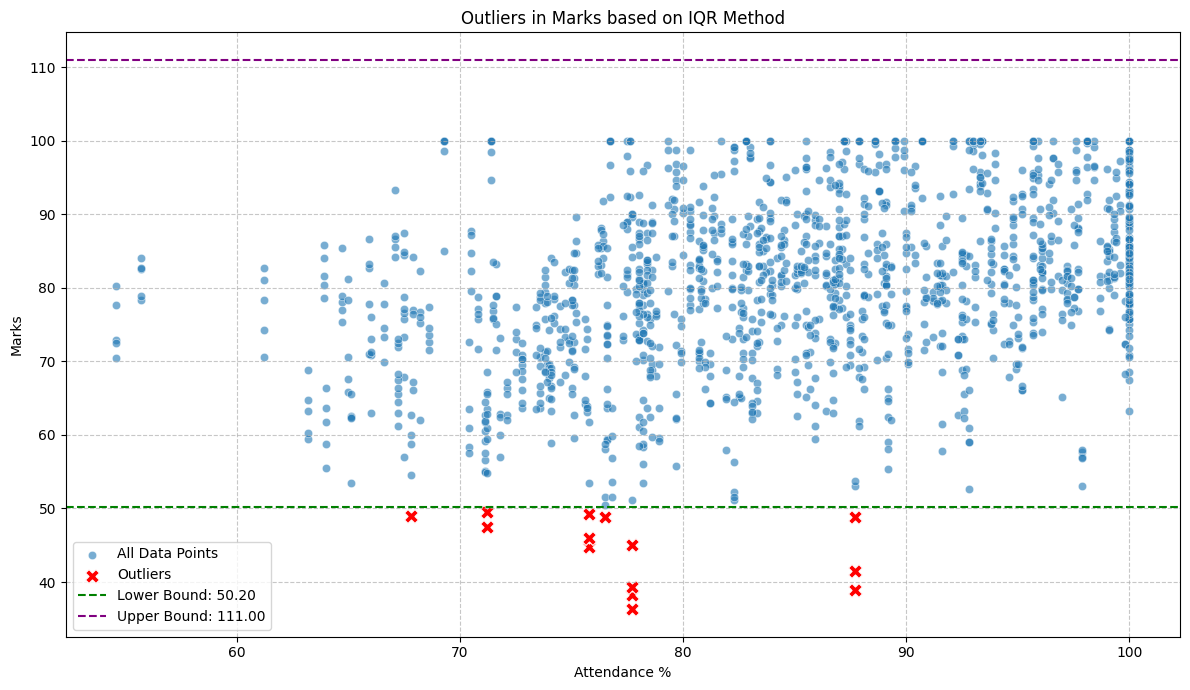

<Figure size 640x480 with 0 Axes>

In [51]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='attendance_%', y='marks', data=df, alpha=0.6, label='All Data Points')
sns.scatterplot(x='attendance_%', y='marks', data=outliers, color='red', s=100, label='Outliers', marker='X')
plt.axhline(y=Lower_bound, color='green', linestyle='--', label=f'Lower Bound: {Lower_bound:.2f}')
plt.axhline(y=Upper_bound, color='purple', linestyle='--', label=f'Upper Bound: {Upper_bound:.2f}')
plt.title('Outliers in Marks based on IQR Method')
plt.xlabel('Attendance %')
plt.ylabel('Marks')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('outliers_in_marks.jpeg')

### Average Marks by Test Preparation

/tmp/ipykernel_979/1450161378.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_Hypothesis_03.index, y=df_Hypothesis_03['marks'], palette='coolwarm')


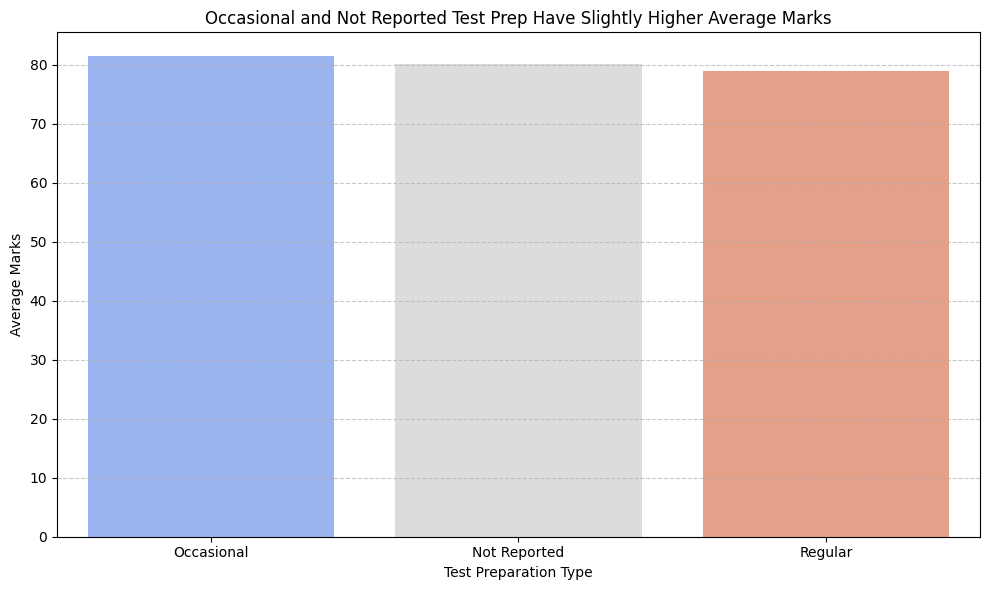

<Figure size 640x480 with 0 Axes>

In [53]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_Hypothesis_03.index, y=df_Hypothesis_03['marks'], palette='coolwarm')
plt.title('Occasional and Not Reported Test Prep Have Slightly Higher Average Marks')
plt.xlabel('Test Preparation Type')
plt.ylabel('Average Marks')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.savefig('average_marks_by_test_preparation.jpeg')

### Student Performance Analysis Project - Key Findings Dashboard

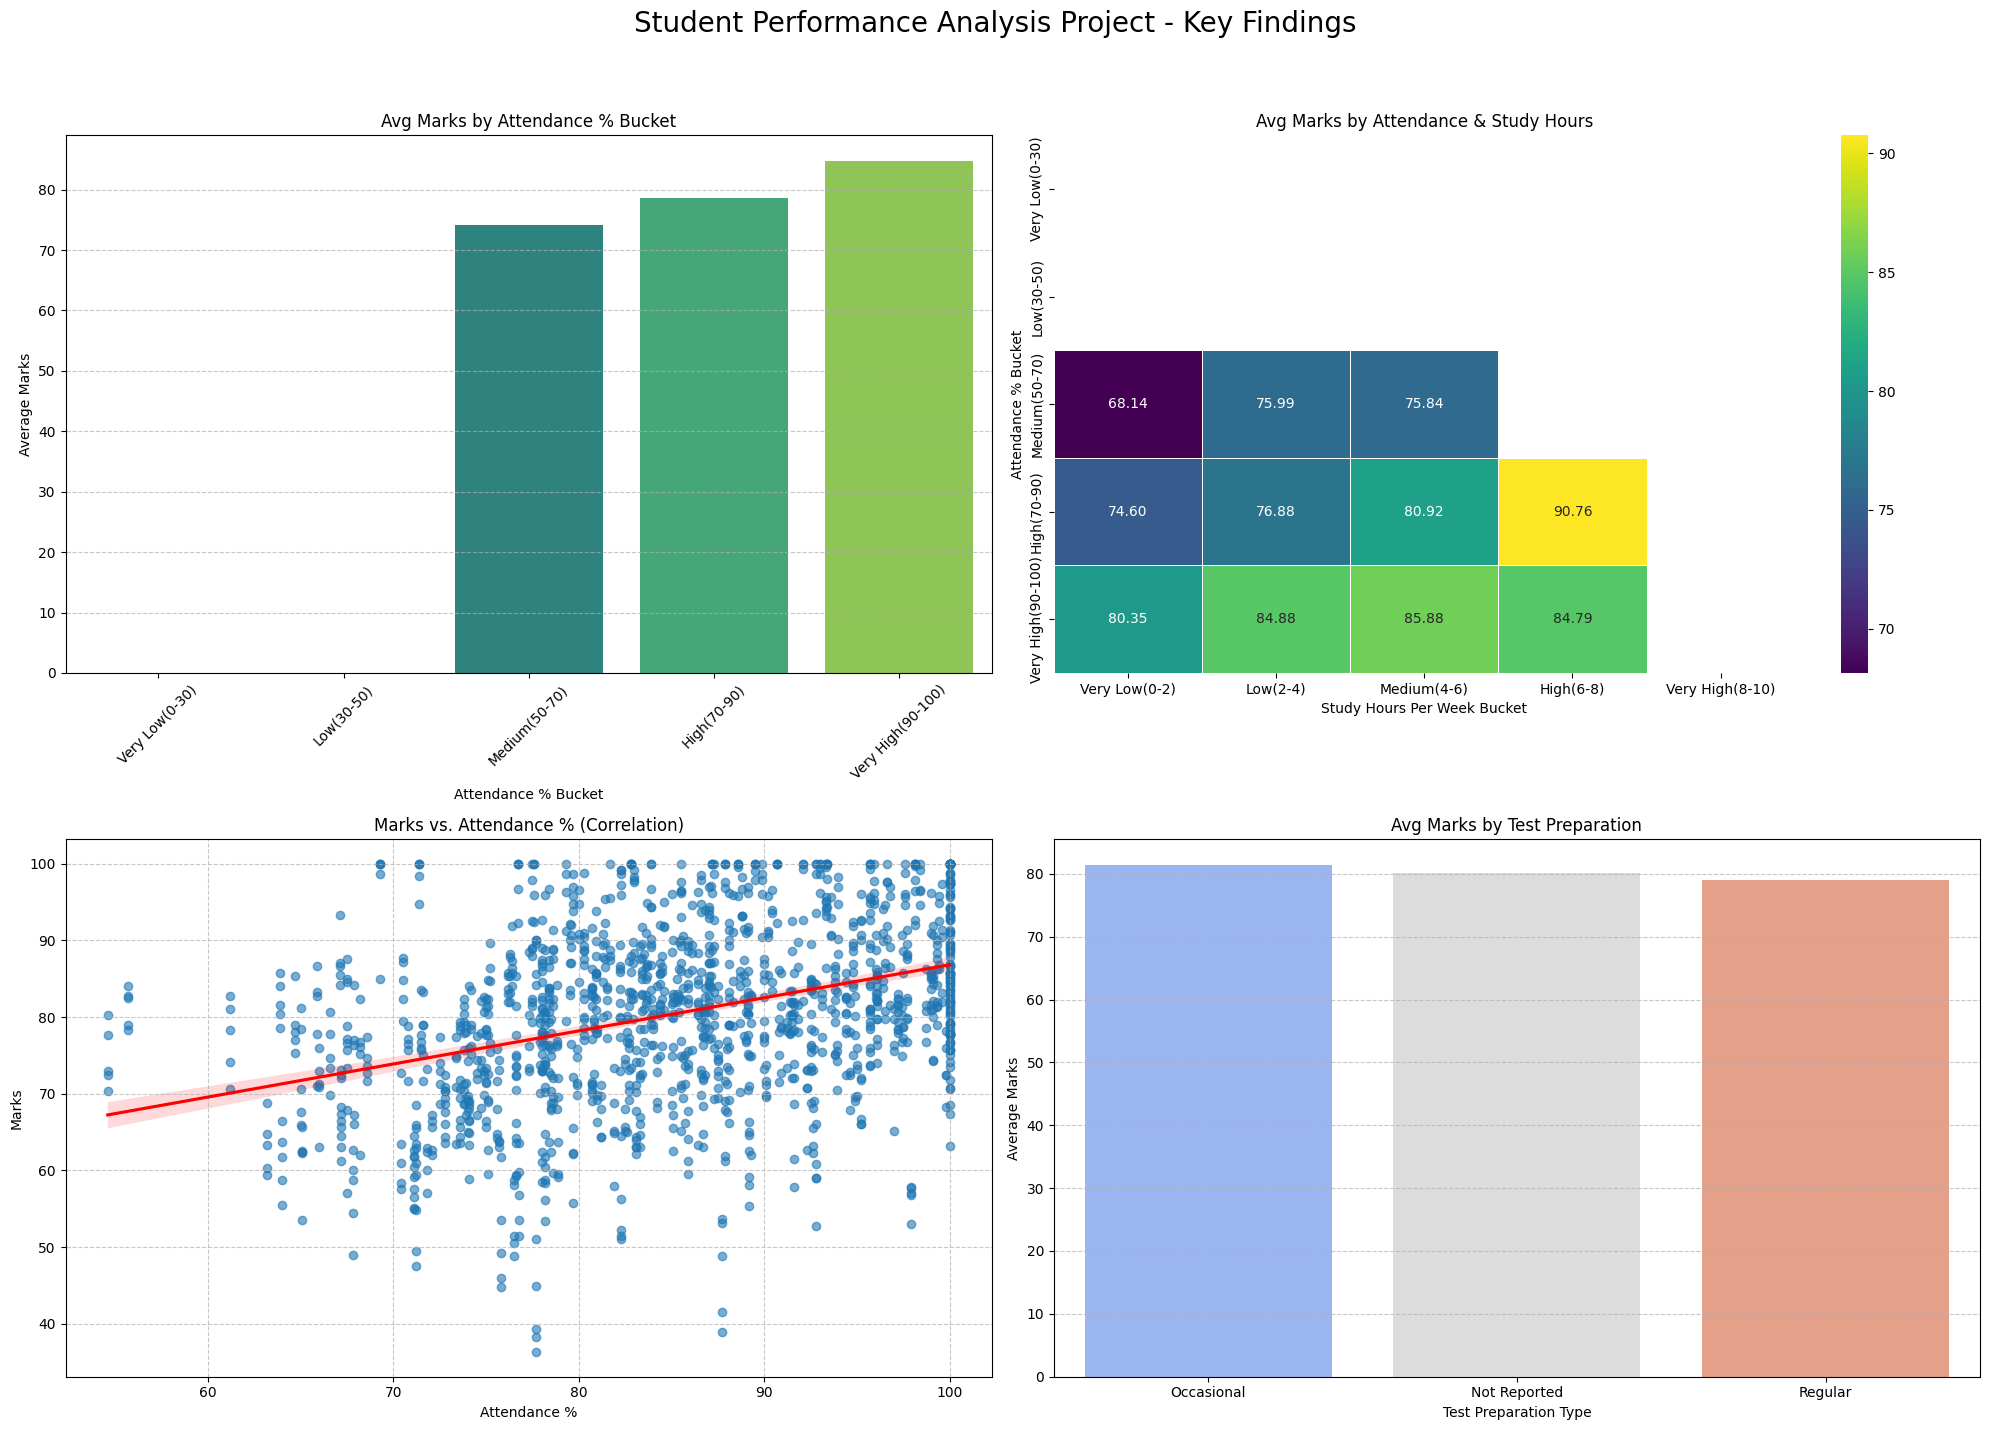

<Figure size 640x480 with 0 Axes>

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Student Performance Analysis Project - Key Findings', fontsize=20)

# Plot 1: Students who fall in higher attendance bucket tend to score overall average marks
sns.barplot(x=df_Hypothesis_01.index, y=df_Hypothesis_01['marks'], hue=df_Hypothesis_01.index, palette='viridis', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Avg Marks by Attendance % Bucket')
axes[0, 0].set_xlabel('Attendance % Bucket')
axes[0, 0].set_ylabel('Average Marks')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Average Marks by Attendance % Bucket and Study Hours Per Week Bucket (Heatmap)
sns.heatmap(df_heatmap_data, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, ax=axes[0, 1])
axes[0, 1].set_title('Avg Marks by Attendance & Study Hours')
axes[0, 1].set_xlabel('Study Hours Per Week Bucket')
axes[0, 1].set_ylabel('Attendance % Bucket')

# Plot 3: Marks and Attendance Percentage are Positively Moderately Correlated
sns.regplot(x='attendance_%', y='marks', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'}, ax=axes[1, 0])
axes[1, 0].set_title('Marks vs. Attendance % (Correlation)')
axes[1, 0].set_xlabel('Attendance %')
axes[1, 0].set_ylabel('Marks')
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 4: Average Marks by Test Preparation (Bar Chart)
sns.barplot(x=df_Hypothesis_03.index, y=df_Hypothesis_03['marks'], hue=df_Hypothesis_03.index, palette='coolwarm', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Avg Marks by Test Preparation')
axes[1, 1].set_xlabel('Test Preparation Type')
axes[1, 1].set_ylabel('Average Marks')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()
plt.savefig('student_performance_dashboard.jpeg')

In [ ]:
# You are a data analyst preparing a written narrative for a business audience.

# VERIFIED FINDINGS (in order of relevance):
#Students who fall in higher attendance bucket tends to score overall average marks
#study_hours per week is almost directly proportional to marks
#Students attending 70%-90% of classes and studying 6-8hrs per week have the best average marks of 90.69
#Students attending 50-70% of classes and studying 0-2hrs per week have the lowest average marks of 68.14
#Marks and attendance percent are positvely moderately correlated(0.37)
#Parental_education doesn't affect students marks


# TASK: Write a data narrative using the SCR structure:
# Situation (2-3 sentences): establish the business context
# Complication (3-4 sentences): introduce the return problem
# Resolution (3-4 sentences): explain the root cause + recommendation


# CONSTRAINTS:
# - Use exact numbers — do not round or invent
# - Every claim must trace to one of the five findings
# - Recommendation must name WHO should act, WHAT specifically,and UNDER WHAT CONDITIONS
# - No bullet points — continuous prose
# - Maximum 250 words

In [ ]:
#Story Telling

#Student academic performance shows a clear connection with students’ attendance
#and study habits. Students who fall into higher attendance buckets tend to achieve higher average marks,
#while study hours per week are almost directly proportional to marks. This relationship is also reflected
#in the moderate positive correlation of 0.37 between attendance percent and marks.

#The difference becomes especially visible when attendance and study time are considered together.
#Students attending 70%-90% of classes and studying 6-8hrs per week achieve the highest average marks of 90.69.
#In contrast, students attending 50-70% of classes and studying 0-2hrs per week have the lowest average marks of 68.14.
#Parental education does not affect students marks, indicating that the stronger performance patterns are associated
#with attendance and study habits rather than parental education.

#Academic coordinators should therefore focus their support on students with
#50-70% attendance and 0-2hrs of weekly study, specifically encouraging them to
#improve attendance and increase study time toward 6-8hrs per week. The 70%-90%
#attendance and 6-8hrs study pattern can serve as a target because it is associated
#with the highest average marks of 90.69.


In [ ]:
"""
# Student Performance Analysis Project

## Overview
This project aims to analyze various factors influencing student academic performance using a given dataset. Through data cleaning, exploratory data analysis, hypothesis testing, and advanced visualization techniques, key insights into student success were identified.

## Workflow

1.  **Data Loading and Preprocessing**: The `raw_student_data.csv` dataset was loaded. Missing values in numerical columns were imputed using the mean. Duplicate entries were identified and removed. The `test_preparation` column was cleaned by standardizing text and filling missing values with 'Not Reported'.
2.  **Exploratory Data Analysis (EDA) and Hypothesis Testing**: Several hypotheses were formulated and tested to understand relationships between different student attributes (e.g., attendance, study hours, parental education, gender, grade, subject) and their marks.
3.  **Advanced EDA Techniques**:
    *   **Multi-level Segmentation**: Students were grouped by 'attendance % bucket' and 'study hours per week bucket' to analyze average marks across these segments.
    *   **Correlation Analysis**: The correlation between 'marks' and 'attendance %' was calculated to quantify their relationship.
    *   **Outlier Detection**: The IQR method was applied to identify extreme values in the 'marks' column.
4.  **Visualization**: Individual plots (bar charts, heatmaps, scatter plots with regression lines) were created to illustrate specific findings. A final 2x2 dashboard was then generated to consolidate the most impactful visualizations.
5.  **Data Narrative**: A structured data narrative (using the SCR framework) was developed to explain the project's key findings and provide actionable recommendations.

## Tools Used

*   **Python**: The primary programming language for data analysis.
*   **Pandas**: Utilized for data manipulation, cleaning, and aggregation.
*   **NumPy**: Used for numerical operations, especially with statistical calculations.
*   **Matplotlib**: Employed for creating static, interactive, and animated visualizations.
*   **Seaborn**: Used for drawing attractive and informative statistical graphics.

## Key Findings

Based on the analysis, the following key findings were observed:

*   **Attendance and Marks**: Students who fall into higher attendance buckets consistently tend to score higher overall average marks. A moderate positive correlation of 0.37 was found between attendance percentage and marks.
*   **Study Hours and Marks**: Study hours per week are almost directly proportional to marks, indicating a strong positive relationship.
*   **Combined Impact of Attendance and Study Hours**: Students attending 70%-90% of classes and studying 6-8 hours per week achieved the highest average marks (90.69). Conversely, students with 50-70% attendance and 0-2 hours of study per week had the lowest average marks (68.14).
*   **Test Preparation**: Students with 'Occasional' and 'Not Reported' test preparation types showed slightly higher average marks compared to those with 'Regular' preparation.
*   **Parental Education, Gender, and Grade**: No significant effect on student marks was observed from parental education, gender, or grade level.

These findings suggest that attendance and consistent study habits are critical determinants of student performance.
"""